# 機械学習ことはじめ②
目的:
 - とりあえずLightGBM→SHAP, というお決まりの流れを見る  
 （このデータでこの流れが美味しいかどうかはさておき）
&nbsp;  
  
動かし方:
1. Google Colab https://colab.research.google.com/ を開く
1. 左上の「ファイル」から「ノートブックを開く」を選択する
1. 開いたウィンドウの左メニューから「GitHub」を選択する
1. URLの欄にGitHubにおけるノートブックのURLを入れる
1. Google Colab上でノートブックが開けたらそれを実行する

## 準備

### 各種依存関係のインストール

In [ ]:
#@title Dependencies
import sys
import pandas as pd
import numpy as np

from functools import partial

import sklearn
from sklearn.metrics import accuracy_score, log_loss, roc_auc_score, classification_report, average_precision_score
from sklearn.model_selection import cross_validate, train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

import lightgbm

!pip install optuna
import optuna

!pip install shap
import shap

### 公共データの取得
https://www.openml.org/search?type=data&sort=runs&id=5&status=active  
年齢、性別、身長、体重、心電図の各指標（すごくたくさんある）、心電図診断  
`class`に心電図診断が入っていて、これを目的変数にします  
今回は虚血性心疾患を見つけることを目的にしてみましょう  

In [ ]:
#@title OpenML `arrhythmia` data
data = fetch_openml(data_id=5, as_frame=True, parser='auto').frame
(data)

,age,sex,height,weight,QRSduration,PRinterval,Q-Tinterval,Tinterval,Pinterval,QRS,...,chV6_QwaveAmp,chV6_RwaveAmp,chV6_SwaveAmp,chV6_RPwaveAmp,chV6_SPwaveAmp,chV6_PwaveAmp,chV6_TwaveAmp,chV6_QRSA,chV6_QRSTA,class
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447,53,1,160,70,80,199,382,154,117,-37,...,0.0,4.3,-5.0,0.0,0.0,0.7,0.6,-4.4,-0.5,1
448,37,0,190,85,100,137,361,201,73,86,...,0.0,15.6,-1.6,0.0,0.0,0.4,2.4,38.0,62.4,10
449,36,0,166,68,108,176,365,194,116,-85,...,0.0,16.3,-28.6,0.0,0.0,1.5,1.0,-44.2,-33.2,2
450,32,1,155,55,93,106,386,218,63,54,...,-0.4,12.0,-0.7,0.0,0.0,0.5,2.4,25.0,46.6,1


### 前処理 (Preprocessing)  
やっていること  
1. 欠損が "?" で入力されているのでこれを`np.nan`に置き換える  
2. 全部数値に変換、失敗するようなら`Nan`でよい（※ここで元々はfactorだったclassが数値に変換されている）
3. 列名`class`を`target`に変更する（pythonの仕様上、`class`のままだと扱いづらいため）
4. 虚血性心疾患 (2) を`1`, それ以外を`0`に振り分ける
5. データ欠損が5%未満の変数だけ残す
6. それでも残った欠損は雑に中央値で埋める
7. 変動が少ない変数（95%以上の例で値が同じであるような変数）を捨てる
8. 強い相関のある変数（相関係数の絶対値が0.9超）の片方を捨てる  
&nbsp;  

7, 8は実際の仕事でも割とよくやる手順です  
 - データ内でバラツキが少ない変数は入れていても予測に寄与するとは考え難い  
 - 強い相関のある変数同士は片方だけで情報量としては十分  

ただ、閾値や選定基準は本来はもっとデータの意味を考えて決めるものです  
今回は例示用にざっくり削りたいので、適当に閾値を決めて落としています  
&nbsp;  
  
※コードは結構gemini君に訊きながら書いてます  
※正直R, tidyverse環境でやるほうが遥かに楽だと思います  
※余談: https://share.google/aimode/Dj6mlIvlIvyeQluaz

In [ ]:
#@title Preprocessing
data_df = data.replace(
        "?", np.nan
    ).apply(
        pd.to_numeric, errors="coerce"
    ).rename(
        columns={"class": "target"}
    ).assign(
        target = lambda x: x["target"].isin([2]).astype(int)
    ).pipe(
        lambda x: x.loc[:, x.isnull().mean() < 0.05]
    ).pipe(
        lambda x: x.fillna(x.median(numeric_only=True))
    ).pipe(
        lambda x: x.loc[:, (x.apply(lambda col: col.value_counts(normalize=True).max()) < 0.95) | (x.columns == "target") ]
    ).pipe(
        lambda x: (
            x.drop(columns=
                x.corr().abs()
                .where(np.triu(np.ones(x.corr().shape), k=1).astype(bool))
                .pipe(lambda df: [c for c in df.columns if any(df[c] > 0.9)])
            )
        )
    )

(data_df)

,age,sex,height,weight,QRSduration,PRinterval,Q-Tinterval,Tinterval,Pinterval,QRS,...,chV5_QRSTA,chV6_JJwaveAmp,chV6_QwaveAmp,chV6_RwaveAmp,chV6_SwaveAmp,chV6_PwaveAmp,chV6_TwaveAmp,chV6_QRSA,chV6_QRSTA,target
0,75,0,190,80,91,193,371,174,121,-16,...,62.9,-0.3,0.0,9.0,-0.9,0.9,2.9,23.3,49.4,0
1,56,1,165,64,81,174,401,149,39,25,...,43.4,-0.5,0.0,8.5,0.0,0.2,2.1,20.4,38.8,0
2,54,0,172,95,138,163,386,185,102,96,...,48.2,0.9,0.0,9.5,-2.4,0.3,3.4,12.3,49.0,0
3,55,0,175,94,100,202,380,179,143,28,...,68.0,0.1,0.0,12.2,-2.2,0.4,2.6,34.6,61.6,0
4,75,0,190,80,88,181,360,177,103,-16,...,48.9,-0.4,0.0,13.1,-3.6,-0.1,3.9,25.4,62.8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
447,53,1,160,70,80,199,382,154,117,-37,...,-0.6,0.0,0.0,4.3,-5.0,0.7,0.6,-4.4,-0.5,0
448,37,0,190,85,100,137,361,201,73,86,...,82.5,-0.5,0.0,15.6,-1.6,0.4,2.4,38.0,62.4,0
449,36,0,166,68,108,176,365,194,116,-85,...,-63.6,1.2,0.0,16.3,-28.6,1.5,1.0,-44.2,-33.2,1
450,32,1,155,55,93,106,386,218,63,54,...,61.0,0.2,-0.4,12.0,-0.7,0.5,2.4,25.0,46.6,0


### ながめてみる
陽性例は452例中44例（9.7%）、不均衡データです  
説明変数はある程度雑に削ったけれどまだ159個残っています  

In [ ]:
#@title Take a glance
print(sum(data_df["target"] == 1))
print(data_df.columns.values)

44
['age' 'sex' 'height' 'weight' 'QRSduration' 'PRinterval' 'Q-Tinterval'
 'Tinterval' 'Pinterval' 'QRS' 'T' 'P' 'QRST' 'heartrate' 'chDI_Qwave'
 'chDI_Rwave' 'chDI_Swave' 'chDI_intrinsicReflecttions' 'chDII_Qwave'
 'chDII_Rwave' 'chDII_Swave' 'chDII_intrinsicReflecttions' 'chDIII_Qwave'
 'chDIII_Rwave' 'chDIII_Swave' 'chDIII_RPwave'
 'chDIII_intrinsicReflecttions' 'chAVR_Qwave' 'chAVR_Rwave' 'chAVR_Swave'
 'chAVR_RPwave' 'chAVR_intrinsicReflecttions' 'chAVL_Qwave' 'chAVL_Rwave'
 'chAVL_Swave' 'chAVL_intrinsicReflecttions' 'chAVF_Qwave' 'chAVF_Rwave'
 'chAVF_Swave' 'chAVF_intrinsicReflecttions' 'chV1_Qwave' 'chV1_Rwave'
 'chV1_Swave' 'chV1_RPwave' 'chV1_intrinsicReflecttions' 'chV2_Qwave'
 'chV2_Rwave' 'chV2_Swave' 'chV2_RPwave' 'chV2_intrinsicReflecttions'
 'chV3_Qwave' 'chV3_Rwave' 'chV3_Swave' 'chV3_intrinsicReflecttions'
 'chV4_Qwave' 'chV4_Rwave' 'chV4_Swave' 'chV4_intrinsicReflecttions'
 'chV5_Qwave' 'chV5_Rwave' 'chV5_Swave' 'chV5_intrinsicReflecttions'
 'chV6_Qwave' 'chV6_Rwav

## 使用する関数などの定義
pythonの仕様上、処理の内側から外側に向かう順で書いていくことになるので  
初学者には非常に読みづらい

### Optunaで最適化する目的関数
以下のもの、
 - Optuna trialなる存在 (`trial`)
 - 説明変数たち (`X`)
 - 目的変数=正解ラベル (`y`)
 - 使うcross validationという物体 (`cv`)  

……を入れると、  
 - `trial`から発生したハイパーパラメータの提案に対して、
 - 与えられた`cv`を使ってcross validationをして、
 - cross validationにおける`neg_log_loss` = -1×LogLossの平均を返す

……という関数（しくみ）を書いています  
&nbsp;  
  
ハイパラの探索範囲は`param = { ...... }`の中身です  
`class_weight`を`balanced`で先ぎめにしています  

In [ ]:
#@title Objective function for Optuna
def objective_CLF(trial, X, y, cv):
    param = {
        "objective": "binary",
        "metric": "binary_logloss",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "num_leaves": trial.suggest_int("num_leaves", 2, 256),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leafs", 2, 100),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1.0, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
        "class_weight": trial.suggest_categorical("class_weight", ["balanced"]),
        }

    classifier = lightgbm.LGBMClassifier()
    classifier.set_params(**param)

    scores = cross_val_score(classifier, X, y, cv=cv, scoring="neg_log_loss")

    return scores.mean()

### Inner CV の関数
以下のもの、
 - 訓練用データの説明変数たち (`train_X`)
 - 訓練用データの目的変数=正解ラベル (`train_y`)
 - 評価用データの説明変数たち (`test_X`)
 - 評価用データの目的変数=正解ラベル (`test_y`)
 - してほしいcross validationの回数 (`n_inner`)
 - してほしいOptunaの試行数 (`n_optuna`)
 - 乱数のシード (`random_state`)

……を入れると、  
 - 訓練用データと各種パラメタからOptuna trialとinner CVを作成して、
 - 先ほど定義した目的関数を計算して、
 - その目的関数を最大化 = `neg_log_loss`を最大化 して、
 - Optunaで探索して決めたハイパーパラメータを使って訓練用データで学習して、
 - 評価用データにおける予測までする

……を経て、
 - 学習済みモデル
 - 探索でみつけた最適なハイパーパラメータ
 - 評価用データでの予測（予測値とスコアの両方）

などを返す

……という関数（しくみ）を書いています

In [ ]:
#@title Inner CV function
def innerCV_CLF(train_X, train_y, test_X, test_y, n_inner, n_optuna, random_state):

    # inner CV to use
    cv_inner = StratifiedKFold(n_splits=n_inner, shuffle=True, random_state=random_state)

    # Hyper parameter tuning with inner CV
    study_icv = optuna.create_study(direction="maximize")
    study_icv.optimize(partial(objective_CLF, X=train_X, y=train_y, cv=cv_inner), n_trials = n_optuna, show_progress_bar = False)

    # Learn whole train set with best parameters
    clf_icv = lightgbm.LGBMClassifier(**study_icv.best_params).fit(train_X, train_y)

    # Make predictions
    preds_icv  = clf_icv.predict(test_X)
    scores_icv = clf_icv.predict_proba(test_X)[:,1]

    # Take model metrics
    AUROC_icv = roc_auc_score(test_y, scores_icv)

    return {
        "model": "Logistic regression",
        "best_params": study_icv.best_params,
        "classifier": clf_icv,
        "y_true": test_y,
        "y_pred": preds_icv,
        "y_score": scores_icv,
    }

## データの分割
まずNested cross validation (NCV) に使うデータと最終評価 (validation) に使うデータとを切り分けます  
割合はケースバイケース、ここでは10%としました  
正解ラベルの割合に偏りが生じないように`target`での層別化をかけています

In [ ]:
#@title Train test split
# Stratified split based on `target` value

data_ncv, data_validation = train_test_split(
    data_df,
    test_size=0.1,
    stratify=data_df["target"],
    random_state=42
)

## Nested cross validation
ここに書いてあるのはouter CV, 外側の周回です  
ハイパラチューニングで使うinnner CVは既に関数の形で書いてあります  
&nbsp;  

各周回ごとに、
 - `cv_outer`で発生する分割（`target`での層別化つき）に沿ってデータを分割する
 - 説明変数について、訓練データ側で標準化を行う（`scaler.fit_transform`）
 - 訓練データにも**同じスケールでの**標準化を適応する（`scaler.transform`）
 - ハイパラチューニングをしない分類器で訓練・予測をする
 - `icv_CLF`で内側の周回を伴うハイパラチューニング、訓練、予測を一気に行う
 - 指標を表示
 - データを`DataFrame`に保存  

 を行っています  



In [ ]:
#@title Nested cross validation

## Parapeters for ML
n_inner = 5
n_outer = 5
n_optuna = 30

### Scaler
scaler = StandardScaler().set_output(transform="pandas")

### Data frame to store predictions
ncv_preds_df = pd.DataFrame()

### Outer CV to use
cv_outer = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=42)

### Outer CV
for split, (train_idx, test_idx) in enumerate(cv_outer.split(data_ncv, data_ncv["target"])):

    # Split data according to CV
    data_ncv_train = data_ncv.iloc[train_idx,:]
    data_ncv_test = data_ncv.iloc[test_idx,:]

    # Split data for inner CV (train)
    train_X = scaler.fit_transform(data_ncv_train.drop(columns=["target"]))
    train_y = data_ncv_train["target"]

    # Split data for inner CV (test)
    test_X = scaler.transform(data_ncv_test.drop(columns=["target"]))
    test_y = data_ncv_test["target"]

    # Unpenalized LogisticRegression classifier
    ## Fit the classifier
    CLF_noTuning = LogisticRegression(penalty=None, solver="saga", max_iter=10000).fit(train_X, train_y)

    ## Make predictions
    preds_noTuning  = CLF_noTuning.predict(test_X)
    scores_noTuning = CLF_noTuning.decision_function(test_X)


    # LightGBM Classifier with tunings
    ## Inner CV
    ## This objective function does hyperparameter tuning, prediction in test set
    icv_CLF = innerCV_CLF(train_X=train_X, train_y=train_y, test_X=test_X, test_y=test_y, n_inner=n_inner, n_optuna=n_optuna, random_state=42)


    # Print results of this fold
    print(f"fold: {split}, classifier: Unpenalized LogisticRegression, AUROC: ", roc_auc_score(test_y, preds_noTuning))
    print(classification_report(test_y, preds_noTuning))
    print(f"fold: {split}, classifier: LightGBM Classifier with tunings, AUROC: ", roc_auc_score(test_y, icv_CLF["y_pred"]))
    print(classification_report(test_y, icv_CLF["y_pred"]))
    print(f"fold: {split}, classifier: LightGBM Classifier with tunings, best_params: ", icv_CLF["best_params"])


    # Store predictions
    ncv_preds_df = pd.concat([
        ncv_preds_df,
        pd.DataFrame({
            "fold": split,
            "classifier": "Unpenalized LogisticRegression",
            "y_index": test_y.index,
            "y_true": test_y,
            "y_pred": preds_noTuning,
            "y_score": scores_noTuning,
        }),
        pd.DataFrame({
            "fold": split,
            "classifier": "LightGBM Classifier with tunings",
            "y_index": test_y.index,
            "y_true": test_y,
            "y_pred": icv_CLF["y_pred"],
            "y_score": icv_CLF["y_score"],
        }),
    ])

[I 2026-05-12 01:47:52,473] A new study created in memory with name: no-name-5e300383-1e69-4186-ba50-b5390d5ed793
[I 2026-05-12 01:47:52,862] Trial 0 finished with value: -0.5509706567961375 and parameters: {'num_leaves': 13, 'min_data_in_leafs': 99, 'learning_rate': 0.0038832459045774707, 'feature_fraction': 0.44688176023247883, 'bagging_fraction': 0.9366133911540616, 'bagging_freq': 7, 'class_weight': 'balanced'}. Best is trial 0 with value: -0.5509706567961375.
[I 2026-05-12 01:47:53,232] Trial 1 finished with value: -0.6931471630588921 and parameters: {'num_leaves': 46, 'min_data_in_leafs': 73, 'learning_rate': 0.014409926389955476, 'feature_fraction': 0.960514308180769, 'bagging_fraction': 0.41366233145394754, 'bagging_freq': 4, 'class_weight': 'balanced'}. Best is trial 0 with value: -0.5509706567961375.
[I 2026-05-12 01:47:53,996] Trial 2 finished with value: -0.6304684265151828 and parameters: {'num_leaves': 202, 'min_data_in_leafs': 50, 'learning_rate': 0.0012570358783985387, 

fold: 0, classifier: Unpenalized LogisticRegression, AUROC:  0.847972972972973
              precision    recall  f1-score   support

           0       0.97      0.95      0.96        74
           1       0.60      0.75      0.67         8

    accuracy                           0.93        82
   macro avg       0.79      0.85      0.81        82
weighted avg       0.94      0.93      0.93        82

fold: 0, classifier: LightGBM Classifier with tunings, AUROC:  0.7989864864864865
              precision    recall  f1-score   support

           0       0.96      0.97      0.97        74
           1       0.71      0.62      0.67         8

    accuracy                           0.94        82
   macro avg       0.84      0.80      0.82        82
weighted avg       0.94      0.94      0.94        82

fold: 0, classifier: LightGBM Classifier with tunings, best_params:  {'num_leaves': 140, 'min_data_in_leafs': 24, 'learning_rate': 0.07059964373441356, 'feature_fraction': 0.80465815661

[I 2026-05-12 01:48:23,025] A new study created in memory with name: no-name-ace08146-c034-4a84-8cd6-fb8f74242094
[I 2026-05-12 01:48:23,547] Trial 0 finished with value: -0.4748358675556844 and parameters: {'num_leaves': 240, 'min_data_in_leafs': 31, 'learning_rate': 0.005016093106509477, 'feature_fraction': 0.7019901394076735, 'bagging_fraction': 0.9237493497219428, 'bagging_freq': 6, 'class_weight': 'balanced'}. Best is trial 0 with value: -0.4748358675556844.
[I 2026-05-12 01:48:23,899] Trial 1 finished with value: -0.2633204280290085 and parameters: {'num_leaves': 60, 'min_data_in_leafs': 43, 'learning_rate': 0.16959112640327997, 'feature_fraction': 0.5955020597867211, 'bagging_fraction': 0.8601530287678683, 'bagging_freq': 4, 'class_weight': 'balanced'}. Best is trial 1 with value: -0.2633204280290085.
[I 2026-05-12 01:48:24,139] Trial 2 finished with value: -0.6218582067377529 and parameters: {'num_leaves': 124, 'min_data_in_leafs': 75, 'learning_rate': 0.0014957928331684376, 'f

fold: 1, classifier: Unpenalized LogisticRegression, AUROC:  0.4452054794520548
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        73
           1       0.00      0.00      0.00         8

    accuracy                           0.80        81
   macro avg       0.45      0.45      0.45        81
weighted avg       0.80      0.80      0.80        81

fold: 1, classifier: LightGBM Classifier with tunings, AUROC:  0.6669520547945206
              precision    recall  f1-score   support

           0       0.93      0.96      0.95        73
           1       0.50      0.38      0.43         8

    accuracy                           0.90        81
   macro avg       0.72      0.67      0.69        81
weighted avg       0.89      0.90      0.89        81

fold: 1, classifier: LightGBM Classifier with tunings, best_params:  {'num_leaves': 105, 'min_data_in_leafs': 9, 'learning_rate': 0.046027234142203236, 'feature_fraction': 0.5024928391

[I 2026-05-12 01:48:43,100] A new study created in memory with name: no-name-f488f080-e4df-44c5-bac5-9e52e9bc8301
[I 2026-05-12 01:48:43,907] Trial 0 finished with value: -0.2044727923670123 and parameters: {'num_leaves': 13, 'min_data_in_leafs': 2, 'learning_rate': 0.037922633749009275, 'feature_fraction': 0.9880163797323767, 'bagging_fraction': 0.47436017545076586, 'bagging_freq': 4, 'class_weight': 'balanced'}. Best is trial 0 with value: -0.2044727923670123.
[I 2026-05-12 01:48:44,119] Trial 1 finished with value: -0.623154879771865 and parameters: {'num_leaves': 155, 'min_data_in_leafs': 54, 'learning_rate': 0.0015725930159496521, 'feature_fraction': 0.9567083687595023, 'bagging_fraction': 0.44125359266392383, 'bagging_freq': 6, 'class_weight': 'balanced'}. Best is trial 0 with value: -0.2044727923670123.
[I 2026-05-12 01:48:44,257] Trial 2 finished with value: -0.693147164938591 and parameters: {'num_leaves': 33, 'min_data_in_leafs': 93, 'learning_rate': 0.0030517367195861595, 'f

fold: 2, classifier: Unpenalized LogisticRegression, AUROC:  0.827054794520548
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        73
           1       0.46      0.75      0.57         8

    accuracy                           0.89        81
   macro avg       0.72      0.83      0.75        81
weighted avg       0.92      0.89      0.90        81

fold: 2, classifier: LightGBM Classifier with tunings, AUROC:  0.8544520547945206
              precision    recall  f1-score   support

           0       0.97      0.96      0.97        73
           1       0.67      0.75      0.71         8

    accuracy                           0.94        81
   macro avg       0.82      0.85      0.84        81
weighted avg       0.94      0.94      0.94        81

fold: 2, classifier: LightGBM Classifier with tunings, best_params:  {'num_leaves': 8, 'min_data_in_leafs': 3, 'learning_rate': 0.035249677651254765, 'feature_fraction': 0.5421550742472

[I 2026-05-12 01:49:01,936] A new study created in memory with name: no-name-9f5d4326-4c39-4112-a02a-6621991b65c0
[I 2026-05-12 01:49:02,305] Trial 0 finished with value: -0.3670459367446889 and parameters: {'num_leaves': 110, 'min_data_in_leafs': 18, 'learning_rate': 0.010794517532704346, 'feature_fraction': 0.692757743571607, 'bagging_fraction': 0.40856306699500566, 'bagging_freq': 7, 'class_weight': 'balanced'}. Best is trial 0 with value: -0.3670459367446889.
[I 2026-05-12 01:49:02,756] Trial 1 finished with value: -0.3622787789208175 and parameters: {'num_leaves': 142, 'min_data_in_leafs': 24, 'learning_rate': 0.23013162621659067, 'feature_fraction': 0.5442574058410176, 'bagging_fraction': 0.7104622625344188, 'bagging_freq': 7, 'class_weight': 'balanced'}. Best is trial 1 with value: -0.3622787789208175.
[I 2026-05-12 01:49:02,910] Trial 2 finished with value: -0.693147164938591 and parameters: {'num_leaves': 174, 'min_data_in_leafs': 97, 'learning_rate': 0.0011739877268920704, 'f

fold: 3, classifier: Unpenalized LogisticRegression, AUROC:  0.6464041095890412
              precision    recall  f1-score   support

           0       0.93      0.92      0.92        73
           1       0.33      0.38      0.35         8

    accuracy                           0.86        81
   macro avg       0.63      0.65      0.64        81
weighted avg       0.87      0.86      0.87        81

fold: 3, classifier: LightGBM Classifier with tunings, AUROC:  0.8407534246575342
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        73
           1       0.55      0.75      0.63         8

    accuracy                           0.91        81
   macro avg       0.76      0.84      0.79        81
weighted avg       0.93      0.91      0.92        81

fold: 3, classifier: LightGBM Classifier with tunings, best_params:  {'num_leaves': 199, 'min_data_in_leafs': 11, 'learning_rate': 0.0362927693371471, 'feature_fraction': 0.47533008656

[I 2026-05-12 01:49:19,258] A new study created in memory with name: no-name-e8608e44-29ff-488f-b7ae-700b8259c3d3
[I 2026-05-12 01:49:19,662] Trial 0 finished with value: -0.4880620184967011 and parameters: {'num_leaves': 107, 'min_data_in_leafs': 33, 'learning_rate': 0.005220867540668357, 'feature_fraction': 0.5444660626451463, 'bagging_fraction': 0.5239578207254417, 'bagging_freq': 6, 'class_weight': 'balanced'}. Best is trial 0 with value: -0.4880620184967011.
[I 2026-05-12 01:49:19,936] Trial 1 finished with value: -0.3035550292398697 and parameters: {'num_leaves': 31, 'min_data_in_leafs': 65, 'learning_rate': 0.04049886421155181, 'feature_fraction': 0.908790363364518, 'bagging_fraction': 0.5279886341037867, 'bagging_freq': 4, 'class_weight': 'balanced'}. Best is trial 1 with value: -0.3035550292398697.
[I 2026-05-12 01:49:20,531] Trial 2 finished with value: -0.4317699033001249 and parameters: {'num_leaves': 20, 'min_data_in_leafs': 22, 'learning_rate': 0.0072159856531229605, 'fea

fold: 4, classifier: Unpenalized LogisticRegression, AUROC:  0.7851027397260274
              precision    recall  f1-score   support

           0       0.96      0.95      0.95        73
           1       0.56      0.62      0.59         8

    accuracy                           0.91        81
   macro avg       0.76      0.79      0.77        81
weighted avg       0.92      0.91      0.92        81

fold: 4, classifier: LightGBM Classifier with tunings, AUROC:  0.8407534246575342
              precision    recall  f1-score   support

           0       0.97      0.93      0.95        73
           1       0.55      0.75      0.63         8

    accuracy                           0.91        81
   macro avg       0.76      0.84      0.79        81
weighted avg       0.93      0.91      0.92        81

fold: 4, classifier: LightGBM Classifier with tunings, best_params:  {'num_leaves': 232, 'min_data_in_leafs': 41, 'learning_rate': 0.060939348270036414, 'feature_fraction': 0.485367708

## 最終モデルの学習と評価
 - NCVに使ったデータ (90%)を学習データにする
 - 説明変数について、訓練データ側で標準化を行う（`scaler.fit_transform`）
 - 訓練データにも**同じスケールでの**標準化を適応する（`scaler.transform`）
 - ハイパラチューニングをしない分類器で訓練・予測をする
 - `icv_CLF`で内側の周回を伴うハイパラチューニング、訓練、予測を一気に行う
 - 指標を表示する
 - データを`DataFrame`に保存  

を行っています  
外側のCVがなくなっただけで、ほかはNCVの内側と一緒です  

In [ ]:
#@title Final modeling

### Parapeters for ML
n_inner = 5
# n_outer = 5 # No longer doing outer CV
n_optuna = 30

### Scaler
scaler = StandardScaler().set_output(transform="pandas")

### Data frame to store predictions
val_preds_df = pd.DataFrame()

# Split data for inner CV (train)
train_X = scaler.fit_transform(data_ncv.drop(columns=["target"]))
train_y = data_ncv["target"]

# Split data for inner CV (test)
test_X = scaler.transform(data_validation.drop(columns=["target"]))
test_y = data_validation["target"]

### Unpenalized LogisticRegression
#### Fit the classifier
CLF_noTuning = LogisticRegression(penalty=None, solver="saga", max_iter=10000).fit(train_X, train_y)

#### Make predictions
preds_noTuning  = CLF_noTuning.predict(test_X)
scores_noTuning = CLF_noTuning.decision_function(test_X)


### LightGBM Classifier with tunings
#### Inner CV
#### This objective function does hyperparameter tuning, prediction in test set
icv_CLF = innerCV_CLF(train_X=train_X, train_y=train_y, test_X=test_X, test_y=test_y, n_inner=n_inner, n_optuna=n_optuna, random_state=42)


### Print results
print(f"fold: {split}, classifier: Unpenalized LogisticRegression, AUROC: ", roc_auc_score(test_y, preds_noTuning))
print(classification_report(test_y, preds_noTuning))
print(f"fold: {split}, classifier: LightGBM Classifier with tunings, AUROC: ", roc_auc_score(test_y, icv_CLF["y_pred"]))
print(classification_report(test_y, icv_CLF["y_pred"]))
print(f"fold: {split}, classifier: LightGBM Classifier with tunings, best_params: ", icv_CLF["best_params"])


# Store predictions
val_preds_df = pd.concat([
    val_preds_df,
    pd.DataFrame({
        "fold": split,
        "classifier": "Unpenalized LogisticRegression",
        "y_index": test_y.index,
        "y_true": test_y,
        "y_pred": preds_noTuning,
        "y_score": scores_noTuning,
    }),
    pd.DataFrame({
        "fold": split,
        "classifier": "LightGBM Classifier with tunings",
        "y_index": test_y.index,
        "y_true": test_y,
        "y_pred": icv_CLF["y_pred"],
        "y_score": icv_CLF["y_score"],
    }),
])

[I 2026-05-12 01:49:38,401] A new study created in memory with name: no-name-fe8d95f6-370c-44fe-8661-e3e9cc686028
[I 2026-05-12 01:49:39,533] Trial 0 finished with value: -0.6113570302639086 and parameters: {'num_leaves': 157, 'min_data_in_leafs': 29, 'learning_rate': 0.0015131711140449618, 'feature_fraction': 0.9809312723935706, 'bagging_fraction': 0.8840810374508465, 'bagging_freq': 5, 'class_weight': 'balanced'}. Best is trial 0 with value: -0.6113570302639086.
[I 2026-05-12 01:49:39,838] Trial 1 finished with value: -0.24016104476593464 and parameters: {'num_leaves': 104, 'min_data_in_leafs': 81, 'learning_rate': 0.10731128390011996, 'feature_fraction': 0.7923525685452096, 'bagging_fraction': 0.8649014549727857, 'bagging_freq': 7, 'class_weight': 'balanced'}. Best is trial 1 with value: -0.24016104476593464.
[I 2026-05-12 01:49:40,538] Trial 2 finished with value: -0.37895427837475587 and parameters: {'num_leaves': 217, 'min_data_in_leafs': 15, 'learning_rate': 0.008736492148667856

fold: 4, classifier: Unpenalized LogisticRegression, AUROC:  0.5654761904761905
              precision    recall  f1-score   support

           0       0.93      0.88      0.90        42
           1       0.17      0.25      0.20         4

    accuracy                           0.83        46
   macro avg       0.55      0.57      0.55        46
weighted avg       0.86      0.83      0.84        46

fold: 4, classifier: LightGBM Classifier with tunings, AUROC:  0.738095238095238
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.67      0.50      0.57         4

    accuracy                           0.93        46
   macro avg       0.81      0.74      0.77        46
weighted avg       0.93      0.93      0.93        46

fold: 4, classifier: LightGBM Classifier with tunings, best_params:  {'num_leaves': 145, 'min_data_in_leafs': 92, 'learning_rate': 0.07264895496081666, 'feature_fraction': 0.71143036057

## SHAP

In [ ]:
#@title Build SHAP
explainer = shap.TreeExplainer(icv_CLF["classifier"], train_X)
shap_values = explainer(train_X)

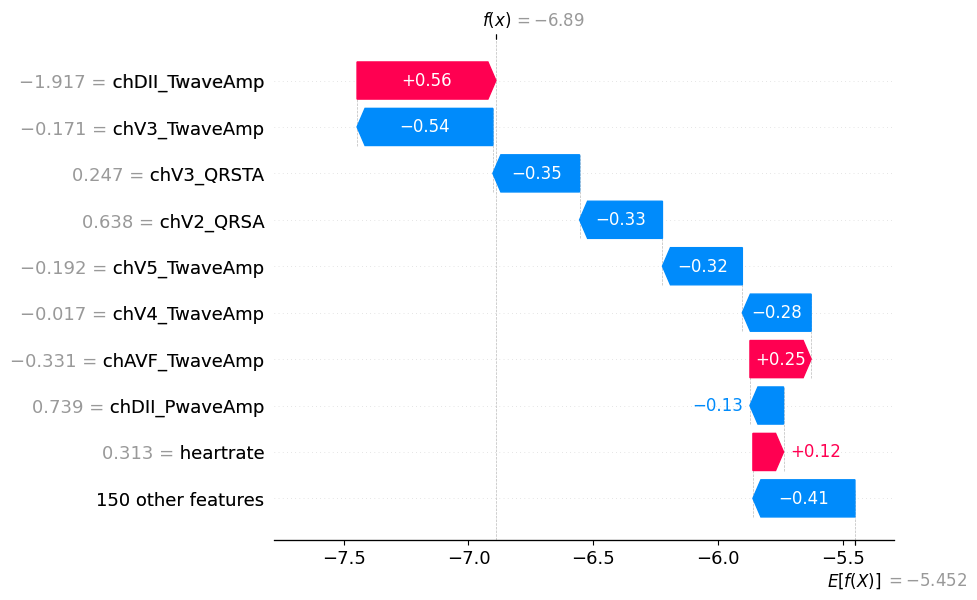

In [ ]:
#@title Waterfall plot
shap.plots.waterfall(shap_values[8])

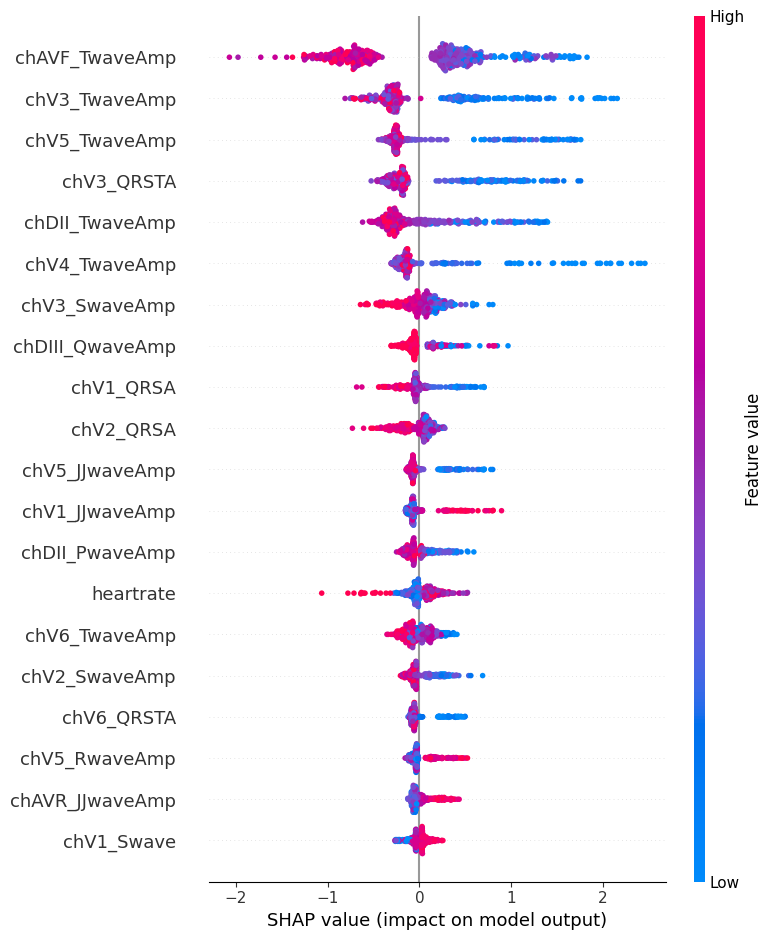

In [ ]:
#@title Summary plot
shap.summary_plot(shap_values, plot_type="dot")

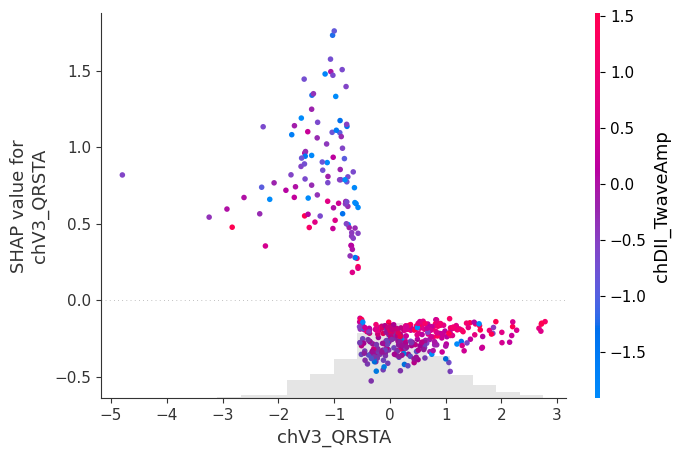

In [ ]:
#@title Scatter plot
shap.plots.scatter(shap_values[:, "chV3_QRSTA"], color=shap_values)

## Session Info

In [ ]:

## Session Info
print(sys.version)
!pip freeze

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.5
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.0.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.4.20.0.58.15
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.11
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.39.0
bigquery-magics==0.14.0
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cach